In [1]:
# illustrative example of use VeraRubin 

# Example of warping visits

> Version: 1.0
> 
> Container Size: Large

> Description:  In this notebook, we present an illustrative example of using the warp procedure from the VeraRubin package.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Complementary info
! echo $IMAGE_DESCRIPTION
! eups list -s | grep lsst_distrib

Release r29.2.0 (RSP Build 2648)
lsst_distrib          gc675d380bf+f75de59d28 	current v29_2_0 v29_2_0_rc1 setup


In [3]:
# Loading modules
import matplotlib.pyplot as plt
import VeraRubin as vr
import numpy as np
import lsst.geom

from lsst.daf.butler import Butler
from astropy.wcs import WCS

## Local repo Butler

In [4]:
LOCAL_REPO = "./local_butler" 

ra_deg, dec_deg = (53.2, -27.8)
loc_data = ra_deg, dec_deg

In [6]:
print("List of avalibles colections:")
# Collections
!butler query-collections --chains 'TREE' $LOCAL_REPO

List of avalibles colections:
                            Name                              Type 
----------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                            RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                            RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z   RUN    
custom_coadd/20260303T072414Z                               RUN    
custom_coadd/inputs                                         TAGGED 
custom_coadd_without_stamp                                  CHAINED
  custom_coadd_without_stamp/20260303T080727Z               RUN    
  custom_coadd_without_stamp/inputs                         TAGGED 
custom_coadd_without_stamp/20260303T080727Z                 RUN    
custom_coadd_without_stamp/inputs                           TAGGED 
direct_injected_run                                         RUN    
local_main_chain                                            CHAINED
  skymaps         

In [12]:
main_collection = "local_main_chain"

## Warping

In [20]:
visit_warps, visit_refs = vr.custom_warp(REPO=LOCAL_REPO,
                                         collections=main_collection,
                                         loc=loc_data, band="u", instrument="LSSTComCam",
                                         datasetType="visit_image", skymap_name="lsst_cells_v1",
                                         # Optional advanced features
                                         filter_by_patch=False,        # use tract/patch to restrict visits
                                         filter_by_region=False,      # use visit_detector_region (if available)
                                         detectors=None,              # allowed detectors
                                         LOGDIR=LOCAL_REPO+"/warps",
                                         out=False,  # True give the results, False put to the repository REPO
                                         run_name="direct_warp_run",
                                         name_chain="local_with_warps",
                                        )

2026-03-04 04:37:29 [INFO] Created LOGDIR at ./local_butler/warps


2026-03-04 04:37:29 [INFO] Starting warping process...


2026-03-04 04:37:29 [INFO] Selecting visits overlapping the patch...


2026-03-04 04:37:29 [INFO] Loading the butler...


2026-03-04 04:37:29 [INFO] [SELECT] Tract=5063, Patch=Index2D(x=4, y=3)


...

2026-03-04 04:39:50 [INFO] Processing visit 2024120100187


2026-03-04 04:40:02 [INFO] [PUT] directWarp saved: visit=2024120100187, detector=6, tract=5063, patch=34


2026-03-04 04:40:02 [INFO] Processing visit 2024120100188


2026-03-04 04:40:12 [INFO] [PUT] directWarp saved: visit=2024120100188, detector=6, tract=5063, patch=34


2026-03-04 04:40:12 [INFO] Warping process completed.


In [5]:
# Notice how now appear the new RUN and chain 
!butler query-collections --chains 'TREE' $LOCAL_REPO

                             Name                               Type 
------------------------------------------------------------- -------
LSSTComCam/runs/DRP/DP1/DM-51335                              RUN    
LSSTComCam/runs/DRP/DP1/DM-53601                              RUN    
LSSTComCam/runs/DRP/DP1/v29_0_0/DM-50260/20250416T185152Z     RUN    
custom_coadd/20260303T072414Z                                 RUN    
custom_coadd/inputs                                           TAGGED 
custom_coadd_without_stamp                                    CHAINED
  custom_coadd_without_stamp/20260303T080727Z                 RUN    
  custom_coadd_without_stamp/inputs                           TAGGED 
custom_coadd_without_stamp/20260303T080727Z                   RUN    
custom_coadd_without_stamp/inputs                             TAGGED 
direct_injected_run                                           RUN    
direct_warp_run                                               RUN    
local_main_chain    

In [9]:
# New Dataset types
print("List of avalibles datasetType:")
!butler query-dataset-types --verbose $LOCAL_REPO

List of avalibles datasetType:
             name                                                      dimensions                                          storage class   
------------------------------ ----------------------------------------------------------------------------------------- ------------------
assembleDeepCoadd_config       []                                                                                        Config            
assembleDeepCoadd_log          ['band', 'skymap', 'tract', 'patch']                                                      ButlerLogRecords  
assembleDeepCoadd_metadata     ['band', 'skymap', 'tract', 'patch']                                                      TaskMetadata      
compare_warp_artifact_mask     ['band', 'instrument', 'skymap', 'day_obs', 'physical_filter', 'tract', 'patch', 'visit'] Mask              
deep_coadd                     ['band', 'skymap', 'tract', 'patch']                                                      Exposure

## Visualizing the results

In [7]:
main_collection = "local_with_warps"
lbutler = Butler(LOCAL_REPO, collections=main_collection)

In [36]:
# Accessing the warped Ids
refs_warp = lbutler.query_datasets("directWarp")

refs_visit_image = np.array(lbutler.query_datasets("visit_image"), dtype=object)
refs_visit_image_id = {ref.dataId.get('visit'): ref for ref in  refs_visit_image}

visit_refs_visit_image, visit_refs_warped = [], []
for ref in refs_warp:
    visit_id = ref.dataId.get('visit')
    
    visit_refs_warped.append(ref)
    visit_refs_visit_image.append(refs_visit_image_id[visit_id])

In [41]:
# Accesing to the original visits
exposures_data = np.array([[ref.dataId['visit'],
    lbutler.get("visit_image", dataId=ref.dataId)] for ref in visit_refs_visit_image[:3]], dtype=object)

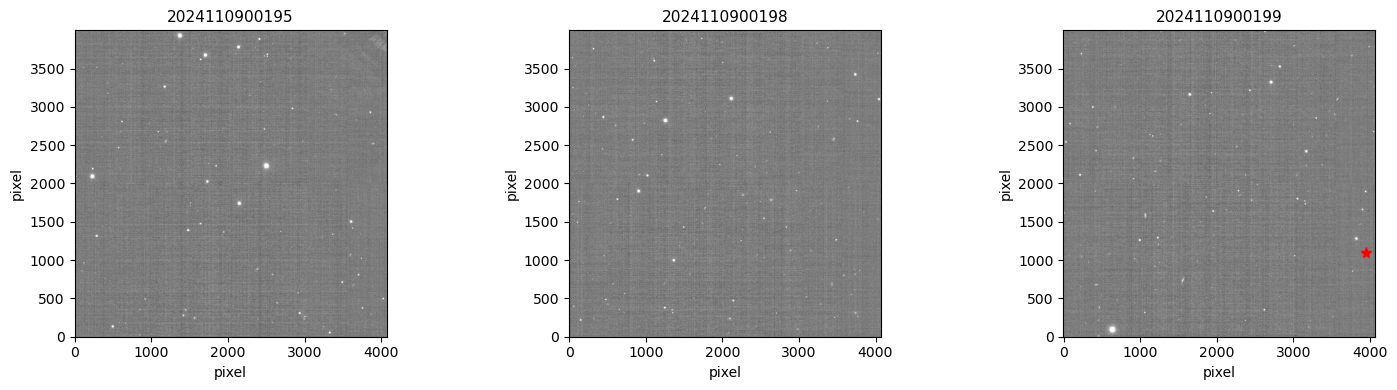

In [60]:
point_sky = lsst.geom.SpherePoint(ra_deg, dec_deg, lsst.geom.degrees)

vr.plot_exposures_full(exposures_data[:,1],
                       center_coord=point_sky,
                       exposures_scale='percentile',
                       titles=list(map(str, exposures_data[:,0])),
                       axeslabels=['pixel', 'pixel'],
                       grid=False)

In [48]:
# Accesing to the warps
visit_warps = np.array([[ref.dataId['visit'],
    lbutler.get("directWarp", dataId=ref.dataId)] for ref in visit_refs_warped[:3]], dtype=object)

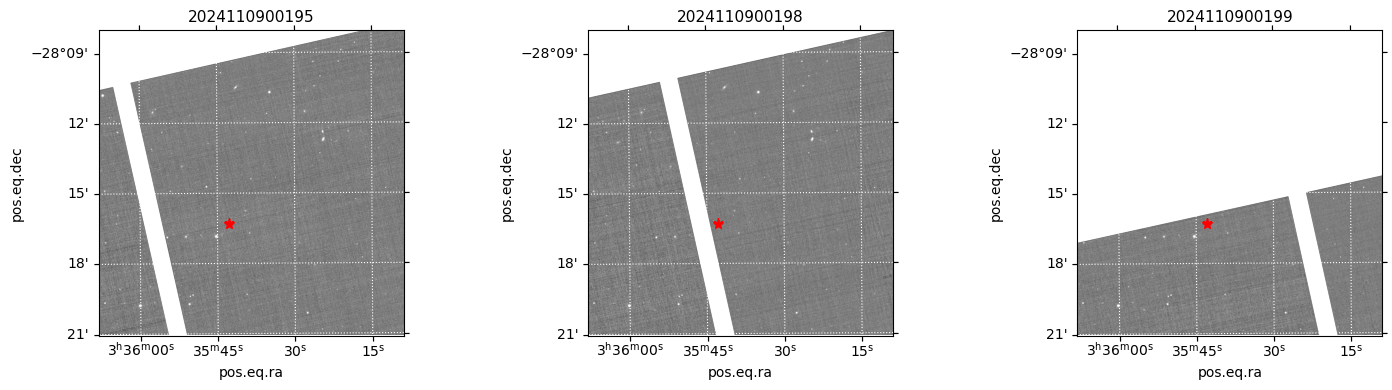

In [61]:
point_sky = lsst.geom.SpherePoint(ra_deg, dec_deg, lsst.geom.degrees)
awcs = WCS(visit_warps[0, 1].getWcs().getFitsMetadata().toDict())

vr.plot_exposures_full(visit_warps[:,1],
                       center_coord=point_sky,
                       exposures_scale='percentile',
                       titles=list(map(str, visit_warps[:,0])),
                       #axeslabels=['pixel', 'pixel'],
                       projection=awcs,
                       grid=True,
                        )